Question 5

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mqf_hw1.data import load_data

df = load_data()


In [2]:
d = df.copy()
d = d.set_index(d.columns[0])

d.columns = ["us","intl","bond","bill","cpi"]
real = d[["us", "intl", "bond", "bill"]].add(1).div(1 + d["cpi"], axis=0)- 1

bootstrap_data = real[["us", "intl", "bond", "bill"]].dropna()

print(bootstrap_data.shape)

bootstrap_data.head()

(679, 4)


,us,intl,bond,bill
date,,,,
1970-01-31,-0.077844,-0.023959,0.026105,0.004493
1970-02-28,0.053945,-0.018203,0.062266,0.002681
1970-03-31,-0.002444,-0.006162,-0.005503,0.001805
1970-04-30,-0.095931,-0.112195,-0.058266,-0.002341
1970-05-31,-0.057138,-0.076692,-0.009095,0.003631


5a. answer

In [3]:
def block_bootstrap(data,block_size=24,path_length=120):
    n_months = len(data)
    n_blocks = path_length // block_size
    sampled_blocks = []

    for i in range(n_blocks):
        start = np.random.randint(0,n_months - block_size + 1)
        block = data.iloc[start:start + block_size]
        sampled_blocks.append(block)

    simulation = pd.concat(sampled_blocks,ignore_index=True)

    return simulation


np.random.seed(42)

simulation = block_bootstrap(bootstrap_data)

print(simulation.shape)
simulation.head()

np.random.seed(42)

simulations = []

bootstrap_results = []

# Generate the paths ONCE and store them (reuse for every weight)
us_paths = []
intl_paths = []

for i in range(1000):
    sim = block_bootstrap(bootstrap_data)
    us_paths.append(sim["us"].to_numpy())
    intl_paths.append(sim["intl"].to_numpy())

us_paths = np.array(us_paths)      # shape (N_PATHS, 120)
intl_paths = np.array(intl_paths)  # shape (N_PATHS, 120)

# Terminal wealth at each domestic weight
weights = [0.0, 0.25, 0.50, 0.75, 1.0]
rows = []
for w in weights:
    port_ret = w * us_paths + (1 - w) * intl_paths
    terminal = np.prod(1 + port_ret, axis=1)
    rows.append({
        "domestic_weight": w,
        "mean": terminal.mean(),
        "p5": np.percentile(terminal, 5),
        "median": np.median(terminal),
        "p95": np.percentile(terminal, 95),
    })

results = pd.DataFrame(rows).set_index("domestic_weight")
print(results.round(3))

(120, 4)
                  mean     p5  median    p95
domestic_weight                             
0.00             1.953  0.595   1.566  4.505
0.25             2.004  0.675   1.725  4.216
0.50             2.066  0.732   1.873  4.061
0.75             2.142  0.761   1.963  4.151
1.00             2.231  0.769   2.041  4.412


b.

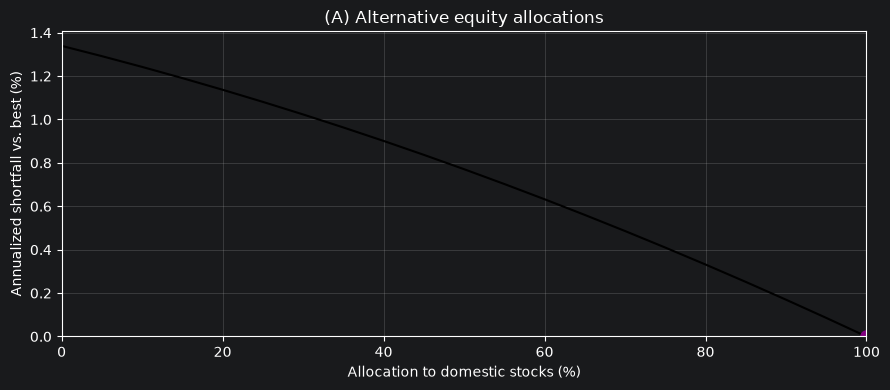

In [6]:
weights = np.linspace(0, 1, 21)   # 0%, 5%, ..., 100%
means = []
for w in weights:
    port_ret = w * us_paths + (1 - w) * intl_paths
    means.append(np.prod(1 + port_ret, axis=1).mean())
means = np.array(means)

best = means.argmax()
# Annualized shortfall vs. the best weight (10-year horizon)
fee = (means[best] / means) ** (1 / 10) - 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(weights * 100, fee * 100, color="black")
ax.plot(weights[best] * 100, 0, "o", color="purple", markersize=8)
ax.set_xlabel("Allocation to domestic stocks (%)")
ax.set_ylabel("Annualized shortfall vs. best (%)")
ax.set_title("(A) Alternative equity allocations")
ax.set_xlim(0, 100)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

5c. In our sample, the mean terminal wealth rises monotonically with the domestic weight, so the best all-equity portfolio is 100% domestic and moving to 05 domestic costs roughly 1.3% per year. This contradicts the paper's flat, wide range around a 34/66 split. The likely explanation is that mean wealth ignores risk and our historical sample favored US stocks, whereas the paper's utility based measure rewards diversification and uses a far larger simulation.

Question 6

a. According to the paper, bonds look safe at short horizons, but that advantage reverses at long horizons. Meanwhile, international stocks become relatively more attractive because their long horizon risk characteristics and diversification benefits improve.
At a short horizon, bonds have relatively low volatility and correlation with US stocks. However, these advantages change substantially over longer horizons. Both bond variance and correlation with US stocks increases, which reduces their diversification benefit. Bonds also provide relatively low real returns and are vulnerable to inflation, which can substantially reduce their purchasing power over a long investment period. As a result, holding bonds for several decades may expose investors to significant inflation and low return risk despite their lower short term volatility.
International stocks become relatively more attractive over longer horizons because they offer substantially higher expected returns while continuing to provide diversification from US stocks. The paper finds that the variance of international stocks relative to their one year variance actually declines at longer horizons, making their long term risk characteristics more favorable as compared to their short term volatility. Therefore, international stocks provide a combination of higher growth potential and diversification that bonds may not provide over long investment periods.

b. The results from our sample understates the paper’s conclusion. While the paper finds that international stocks deserve a large weight, our graph puts the optimum at 100% domestic and makes all international the costly choice, showing no benefits from international diversification. One reason is that our sample is a much shorter time period than the paper’s time period. Our time period, which spans from 1970 to 2026 showcases a length in history where US stocks likely outperformed international stocks for a good portion of our sample. As for international performance, many international stocks did very well in earlier periods, where our sample cuts off and where the majority of the paper’s sample comes from.
Another reason is the short horizon. As stated by the paper, bonds are more appealing in short horizons while international stocks have more benefits as the horizon grows. Comparatively, our sample is a lot shorter, which resulted in bonds being more appealing than international stocks. Additionally within the shorter horizon, the absence of major shocks resulted in different conclusions.

c. Mr. Malkiel could be right based on our analysis, which agrees with him saying that bonds, compared to international stocks, are relatively more attractive because their yields are high. When bond yields are high, investors can earn more income from holding bonds, and newly purchased bonds offer better expected returns than they did when interest rates and yields were very low. As for “high…stock prices”, if stocks are more expensive relative to their underlying earnings and expected future returns, then investors may want to reduce their stock exposure. Mr. Malkiel’s opinion aligns with our analysis because both are focused on the current, short horizon attractiveness of bonds and stocks. As with our sample spanning over a limited period, Mr. Malkiel emphasizes on the attractiveness of stock prices and bond yields over a short horizon. In conclusion, while Mr. Malkiel’s argument could be right based off our analysis, both only take into account the short horizons.
